# Infra-FM: CROMA_base Linear Probe (joint S1 + S2)

Self-contained CROMA evaluation notebook, parallel to
`infra_fm_satlas_s1_eval.ipynb` and `infra_fm_prithvi_eval.ipynb`.
**Does not modify those.**

Model: `CROMA_base` (Fuller, Millard, Green 2023).
- Repo: <https://github.com/antofuller/CROMA>
- Weights: <https://huggingface.co/antofuller/CROMA>
- Loader: clone-free — `wget` the single `use_croma.py` file plus
  `huggingface_hub.hf_hub_download` for the weights. Only deps are `torch`
  and `einops` (already in Colab).
- Joint backbone over co-located Sentinel-1 + Sentinel-2 at 10m. The
  forward returns `{'SAR_GAP', 'optical_GAP', 'joint_GAP'}`; we use
  `joint_GAP` as the linear-probe feature.

## Band mapping (5 of 12 S2 bands are zero-padded — documented limitation)

Our `.npy` storage:
`[B04, B03, B02, B08, B8A, B11, B12, VV, VH]` (indices 0..8).

CROMA expects S2 in this order:
`[B01, B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12, B09]` (12 channels).

| CROMA slot | band | source         |
|-----------:|:-----|:---------------|
| 0          | B01  | **zero-pad**   |
| 1          | B02  | our idx 2      |
| 2          | B03  | our idx 1      |
| 3          | B04  | our idx 0      |
| 4          | B05  | **zero-pad**   |
| 5          | B06  | **zero-pad**   |
| 6          | B07  | **zero-pad**   |
| 7          | B08  | our idx 3      |
| 8          | B8A  | our idx 4      |
| 9          | B11  | our idx 5      |
| 10         | B12  | our idx 6      |
| 11         | B09  | **zero-pad**   |

S1 channels go in CROMA's expected `[VV, VH]` order from our indices `[7, 8]`.

> Coverage caveat: 5 of 12 CROMA S2 channels are zero-padded. Document in
> the writeup; this is a real CROMA-vs-our-data gap, not a notebook bug.

## Normalization

CROMA's native preprocessing divides by `2**16 - 1` for 16-bit S2 and uses
a separate dB-derived scaling for S1. Our tiles are already in mixed scales
(S2 raw reflectance, S1 in dB after `curation/stac_imagery.py`). We apply
`percentile_normalize` (clip to 2-98 percentile, rescale to `[0, 1]`)
**per modality separately** — one shared normalization across the
combined 9 channels would let the S1 dB range clobber the S2 statistics.

This gives bounded `[0, 1]` inputs in the same range CROMA was trained on,
just with a different distribution. The CROMA paper reports their model is
fairly robust to normalization choice; we evaluate empirically.

## Linear-probe protocol

- 25 epochs, batch 16, AdamW lr=1e-3, class weights capped at 10×.
- 7-region multi-sector v1 (13 classes), stratified 0.7/0.15/0.15.
- Frozen backbone; classifier head only.
- **Best-val checkpoint is restored before the held-out test pass** — same
  fix built into the Prithvi notebook (search this notebook for
  `BEST_CKPT_BEFORE_TEST`).

The smoke check (cell 10) defaults to `SMOKE_ONLY = True`. Run cells 1–10
to verify model loads + forward + a single train step; then flip to False
and re-run cells 10 + 11 to start training.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU. Runtime -> Change runtime type -> GPU before training.')


Mounted at /content/drive
GPU available: False


In [2]:
%%capture
# CROMA's only runtime deps are torch + einops (both already in Colab).
# scikit-learn for metrics, huggingface_hub for the weight download.
!pip install -q einops huggingface_hub scikit-learn


In [32]:
import os, sys, urllib.request
from pathlib import Path

CROMA_DIR     = Path('/content/croma_repo')
CROMA_DIR.mkdir(exist_ok=True)
USE_CROMA_PY  = CROMA_DIR / 'use_croma.py'
USE_CROMA_URL = 'https://raw.githubusercontent.com/antofuller/CROMA/main/use_croma.py'

# Pull the single use_croma.py file (skip cloning the whole repo — only
# need this one module). Fall back to git clone if the raw URL is moved.
if not USE_CROMA_PY.exists():
    print(f'Fetching {USE_CROMA_URL} ...')
    try:
        urllib.request.urlretrieve(USE_CROMA_URL, USE_CROMA_PY)
        print(f'  -> {USE_CROMA_PY}  ({USE_CROMA_PY.stat().st_size:,} bytes)')
    except Exception as e:
        print(f'  direct download failed ({e}); falling back to git clone')
        import subprocess
        subprocess.check_call(['git', 'clone', '--depth', '1', '-q',
                               'https://github.com/antofuller/CROMA.git',
                               str(CROMA_DIR)])
        assert USE_CROMA_PY.exists(), 'use_croma.py missing after clone'
else:
    print(f'Already have {USE_CROMA_PY}')

# Download pretrained weights from HF. The CROMA repo on HF has several
# .pt files; try the expected names in priority order. Cache in /root so
# repeat runs are fast.
from huggingface_hub import hf_hub_download

WEIGHT_CANDIDATES = ['CROMA_base.pt', 'croma_base.pt', 'CROMA_base.pth']
CROMA_WEIGHTS = None
last_err = None
for candidate in WEIGHT_CANDIDATES:
    try:
        CROMA_WEIGHTS = hf_hub_download(repo_id='antofuller/CROMA',
                                        filename=candidate)
        print(f'Downloaded weights: {candidate} -> {CROMA_WEIGHTS}')
        break
    except Exception as e:
        last_err = e
        continue
if CROMA_WEIGHTS is None:
    raise RuntimeError(
        f'No CROMA_base weights found on HF. Tried {WEIGHT_CANDIDATES}. '
        f'Last error: {last_err}'
    )

# Make use_croma.py importable
if str(CROMA_DIR) not in sys.path:
    sys.path.insert(0, str(CROMA_DIR))
from use_croma import PretrainedCROMA
print('use_croma.PretrainedCROMA imported OK')


Already have /content/croma_repo/use_croma.py


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


CROMA_base.pt:   0%|          | 0.00/778M [00:00<?, ?B/s]

Downloaded weights: CROMA_base.pt -> /root/.cache/huggingface/hub/models--antofuller--CROMA/snapshots/0dd28e3d633bd6715856ae9890e8c49360040598/CROMA_base.pt
use_croma.PretrainedCROMA imported OK


In [33]:
# Optional: extract the infra_fm curation code zip so any repo helpers are
# importable. The notebook is self-contained (its own dataset class) but
# we honor the project convention of placing repo code at /content/infrabench_repo.
import os, zipfile
from pathlib import Path

DRIVE_ROOT = '/content/drive/MyDrive/infra_fm'
CODE_ZIP   = f'{DRIVE_ROOT}/code/infra_fm_curation.zip'
EXTRACT_TO = '/content/infrabench_repo'

if not Path(f'{EXTRACT_TO}/downstream').exists() and not Path(f'{EXTRACT_TO}/infra_fm_code_only/downstream').exists():
    if Path(CODE_ZIP).exists():
        print(f'Extracting {CODE_ZIP} -> {EXTRACT_TO} ...')
        os.makedirs(EXTRACT_TO, exist_ok=True)
        with zipfile.ZipFile(CODE_ZIP, 'r') as z:
            for member in z.namelist():
                clean = member.replace('\\', '/')
                target = os.path.join(EXTRACT_TO, clean)
                if clean.endswith('/'):
                    os.makedirs(target, exist_ok=True)
                else:
                    os.makedirs(os.path.dirname(target), exist_ok=True)
                    with z.open(member) as src, open(target, 'wb') as dst:
                        dst.write(src.read())
        print('done.')
    else:
        print(f'No code zip at {CODE_ZIP} — notebook is self-contained, OK to skip.')
else:
    print(f'Code already at {EXTRACT_TO}.')

for candidate in [EXTRACT_TO, f'{EXTRACT_TO}/infra_fm_code_only']:
    if Path(candidate).exists() and candidate not in sys.path:
        sys.path.insert(0, candidate)


Code already at /content/infrabench_repo.


In [34]:
import os
from pathlib import Path

# ---- Drive paths -----------------------------------------------------------
DATASETS_DRIVE = f'{DRIVE_ROOT}/datasets'
DATASETS_LOCAL = '/content/datasets'
OUTPUT_DIR     = f'{DRIVE_ROOT}/results/fm_eval_croma_v1'
os.makedirs(OUTPUT_DIR,     exist_ok=True)
os.makedirs(DATASETS_LOCAL, exist_ok=True)

# ---- Coverage --------------------------------------------------------------
REGIONS = [
    'africa', 'asia', 'australia-oceania', 'central-america',
    'europe', 'north-america', 'south-america',
]
SECTORS = ['energy', 'water', 'transport', 'telecom']

# ---- 13-class taxonomy (locked across all FM eval notebooks) ----
CLASS_NAMES = [
    'energy.transmission.substation',
    'energy.distribution.substation',
    'energy.distribution.other',          # pools substation_untyped + substation_minor
    'energy.generation.power_plant',
    'energy.generation.solar_farm',
    'energy.generation.wind_farm',
    'water.wastewater.plant',
    'water.treatment.plant',
    'water.storage_tank',
    'transport.airport',
    'transport.train_station',
    'transport.port_terminal',
    'telecom.data_center',
]
CLASS_TO_IDX        = {n: i for i, n in enumerate(CLASS_NAMES)}
CLASS_IDX_TO_SECTOR = {i: n.split('.')[0] for i, n in enumerate(CLASS_NAMES)}

ASSET_TYPE_MAP = {
    'energy.transmission.substation':         'energy.transmission.substation',
    'energy.distribution.substation':         'energy.distribution.substation',
    'energy.distribution.substation_untyped': 'energy.distribution.other',
    'energy.distribution.substation_minor':   'energy.distribution.other',
    'energy.generation.power_plant':          'energy.generation.power_plant',
    'energy.generation.solar_farm':           'energy.generation.solar_farm',
    'energy.generation.wind_farm':            'energy.generation.wind_farm',
    'water.wastewater.plant':                 'water.wastewater.plant',
    'water.treatment.plant':                  'water.treatment.plant',
    'water.storage_tank':                     'water.storage_tank',
    'transport.airport':                      'transport.airport',
    'transport.train_station':                'transport.train_station',
    'transport.port_terminal':                'transport.port_terminal',
    'telecom.data_center':                    'telecom.data_center',
}

# ---- CROMA band mapping (see markdown header for the full table) -----------
# CROMA S2 channel order: B01, B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12, B09
# Our .npy storage:       [B04, B03, B02, B08, B8A, B11, B12, VV, VH]   indices 0..8
# Entry j of CROMA_S2_FROM_OURS gives the OUR-tile index whose band fills CROMA
# slot j, or -1 if that CROMA slot is to be zero-padded.
CROMA_S2_FROM_OURS = [
    -1,   # 0  B01  -> zero-pad
     2,   # 1  B02  <- our idx 2
     1,   # 2  B03  <- our idx 1
     0,   # 3  B04  <- our idx 0
    -1,   # 4  B05  -> zero-pad
    -1,   # 5  B06  -> zero-pad
    -1,   # 6  B07  -> zero-pad
     3,   # 7  B08  <- our idx 3
     4,   # 8  B8A  <- our idx 4
     5,   # 9  B11  <- our idx 5
     6,   # 10 B12  <- our idx 6
    -1,   # 11 B09  -> zero-pad
]
S1_INDICES_IN_OURS = [7, 8]   # VV at idx 7, VH at idx 8

# Sanity-check the remap covers every available S2 band exactly once and
# the zero-pad slots are non-conflicting. Fail fast if the table is wrong.
assigned = sorted(i for i in CROMA_S2_FROM_OURS if i >= 0)
assert assigned == [0, 1, 2, 3, 4, 5, 6], \
    f'CROMA_S2_FROM_OURS does not cover our 7 S2 indices exactly: {assigned}'
assert sum(1 for i in CROMA_S2_FROM_OURS if i < 0) == 5, \
    'Expected exactly 5 zero-padded CROMA slots'

# ---- Reflectance normalization --------------------------------------------
PERC_LO, PERC_HI = 2.0, 98.0

# ---- Training config -------------------------------------------------------
IMAGE_SIZE = 224              # CROMA can extrapolate position embeddings to 224
SEED       = 42
LP_EPOCHS  = 25
LP_BATCH   = 16
LP_LR      = 1e-3

# ---- Determinism -----------------------------------------------------------
def set_seed(seed: int) -> None:
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print(f'Regions ({len(REGIONS)}): {REGIONS}')
print(f'Sectors:                  {SECTORS}')
print(f'Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}')
print(f'CROMA S2 remap (slot:our_idx, -1=zero-pad):')
for slot, our_idx in enumerate(CROMA_S2_FROM_OURS):
    src = f'our idx {our_idx}' if our_idx >= 0 else 'zero-pad'
    print(f'  slot {slot:>2d}  {src}')
print(f'S1 indices in our tiles:  {S1_INDICES_IN_OURS}  (VV, VH)')
print(f'Image size:               {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'Linear probe:             {LP_EPOCHS} epochs, batch {LP_BATCH}, lr {LP_LR}')
print(f'Output dir:               {OUTPUT_DIR}')


Regions (7): ['africa', 'asia', 'australia-oceania', 'central-america', 'europe', 'north-america', 'south-america']
Sectors:                  ['energy', 'water', 'transport', 'telecom']
Classes (13): ['energy.transmission.substation', 'energy.distribution.substation', 'energy.distribution.other', 'energy.generation.power_plant', 'energy.generation.solar_farm', 'energy.generation.wind_farm', 'water.wastewater.plant', 'water.treatment.plant', 'water.storage_tank', 'transport.airport', 'transport.train_station', 'transport.port_terminal', 'telecom.data_center']
CROMA S2 remap (slot:our_idx, -1=zero-pad):
  slot  0  zero-pad
  slot  1  our idx 2
  slot  2  our idx 1
  slot  3  our idx 0
  slot  4  zero-pad
  slot  5  zero-pad
  slot  6  zero-pad
  slot  7  our idx 3
  slot  8  our idx 4
  slot  9  our idx 5
  slot 10  our idx 6
  slot 11  zero-pad
S1 indices in our tiles:  [7, 8]  (VV, VH)
Image size:               224x224
Linear probe:             25 epochs, batch 16, lr 0.001
Output dir:

In [35]:
import zipfile, shutil, time, re
from pathlib import Path

drive_path = Path(DATASETS_DRIVE)
print(f'Contents of {DATASETS_DRIVE}:')
if drive_path.exists():
    for entry in sorted(drive_path.iterdir()):
        if entry.suffix == '.zip':
            size_gb = entry.stat().st_size / 1e9
            print(f'  {entry.name:<55s} {size_gb:>6.2f} GB')
        elif entry.is_dir():
            print(f'  {entry.name}/  (dir)')
else:
    raise RuntimeError(f'{DATASETS_DRIVE} not found — is Drive mounted?')
print()

MULTISECTOR_RE = re.compile(r'^dataset_([a-z-]+)_(energy|water|transport|telecom)_v1_1k$')

def discover_multisector_sources():
    sources, seen = [], set()
    for entry in sorted(drive_path.iterdir()):
        stem = entry.stem if entry.suffix == '.zip' else entry.name
        m = MULTISECTOR_RE.match(stem)
        if not m:
            continue
        region, sector = m.group(1), m.group(2)
        if region not in REGIONS:
            continue
        key = (region, sector)
        if key in seen:
            continue
        seen.add(key)
        sources.append((region, sector, entry, entry.suffix == '.zip'))
    return sources


def materialize_source(region, sector, src_path, is_zip, force=False):
    folder_name = f'dataset_{region}_{sector}_v1_1k'
    target_dir  = Path(DATASETS_LOCAL) / folder_name
    if not force and (target_dir / 'manifest.json').exists():
        n = len(list((target_dir / 'images').glob('*.npy'))) if (target_dir / 'images').exists() else 0
        print(f'  [DONE]   {region:<22s} {sector:<10s} already present ({n} tiles)')
        return target_dir

    if not is_zip:
        if not (src_path / 'manifest.json').exists():
            print(f'  [EMPTY]  {region:<22s} {sector:<10s} no manifest.json')
            return None
        t0 = time.time()
        print(f'  [COPY]   {region:<22s} {sector:<10s} {src_path.name} ...', end=' ', flush=True)
        if target_dir.exists():
            shutil.rmtree(target_dir)
        shutil.copytree(src_path, target_dir)
        n = len(list((target_dir / 'images').glob('*.npy'))) if (target_dir / 'images').exists() else 0
        print(f'done in {time.time()-t0:.0f}s ({n} tiles)')
        return target_dir

    t0 = time.time()
    print(f'  [EXTRACT]{region:<22s} {sector:<10s} {src_path.name} ...', end=' ', flush=True)
    with zipfile.ZipFile(src_path) as zf:
        names = zf.namelist()
        wrapped_prefix = f'{folder_name}/'
        is_wrapped = any(n.startswith(wrapped_prefix) for n in names)
        if is_wrapped:
            zf.extractall(DATASETS_LOCAL)
        else:
            target_dir.mkdir(parents=True, exist_ok=True)
            zf.extractall(target_dir)
    n = len(list((target_dir / 'images').glob('*.npy'))) if (target_dir / 'images').exists() else 0
    print(f'done in {time.time()-t0:.0f}s ({n} tiles)')
    return target_dir


discovered = discover_multisector_sources()
print(f'Found {len(discovered)} multi-sector v1 sources.\n')

ready = []
print('Materializing:')
for region, sector, src_path, is_zip in discovered:
    local = materialize_source(region, sector, src_path, is_zip)
    if local is None:
        continue
    if (local / 'manifest.json').exists() and any((local / 'images').glob('*.npy')):
        ready.append((region, sector, local))

print(f'\nReady: {len(ready)} (region, sector) pairs')


Contents of /content/drive/MyDrive/infra_fm/datasets:
  dataset_africa_energy_v1_1k.zip                           0.04 GB
  dataset_africa_stac_v1.zip                                0.18 GB
  dataset_africa_telecom_v1_1k.zip                          0.00 GB
  dataset_africa_transport_v1_1k.zip                        0.05 GB
  dataset_africa_water_v1_1k.zip                            0.04 GB
  dataset_asia_energy_v1_1k.zip                             0.04 GB
  dataset_asia_stac_v1.zip                                  0.76 GB
  dataset_asia_telecom_v1_1k.zip                            0.00 GB
  dataset_asia_transport_v1_1k.zip                          0.04 GB
  dataset_asia_water_v1_1k.zip                              0.05 GB
  dataset_australia-oceania_energy_v1_1k.zip                0.05 GB
  dataset_australia-oceania_stac_v1.zip                     0.11 GB
  dataset_australia-oceania_telecom_v1_1k (1).zip           0.00 GB
  dataset_australia-oceania_telecom_v1_1k.zip               0.

In [37]:
import json
import numpy as np
import torch
import torch.nn.functional as F
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from collections import Counter
import random


@dataclass
class _Record:
    path: 'Path'
    asset_id: str
    asset_type: str


def percentile_normalize(arr: np.ndarray, lo: float = PERC_LO, hi: float = PERC_HI) -> np.ndarray:
    img = arr.astype(np.float32)
    low  = np.percentile(img, lo)
    high = np.percentile(img, hi)
    if high <= low:
        return np.clip(img / 255.0, 0.0, 1.0)
    return np.clip((img - low) / (high - low), 0.0, 1.0)


class CROMADataset(Dataset):
    """Loads a single dataset_<region>_<sector>_v1_1k/ folder and returns
    a 14-channel CROMA-ready tensor per sample.

    Channel layout of the returned `image` tensor: shape (14, H, W).
      [0..11] = S2 in CROMA band order (5 channels zero-padded, see config cell)
      [12, 13] = S1 [VV, VH] in CROMA's expected order

    The backbone splits this back into `optical_images` (12 ch) and
    `SAR_images` (2 ch) for the joint encoder.
    """
    def __init__(self, dataset_root,
                 croma_s2_from_ours=CROMA_S2_FROM_OURS,
                 s1_indices=S1_INDICES_IN_OURS,
                 allowed_asset_types=tuple(ASSET_TYPE_MAP.keys())):
        self.dataset_root = Path(dataset_root)
        self.croma_s2_from_ours = list(croma_s2_from_ours)
        self.s1_indices         = list(s1_indices)
        # Bands we actually pull from disk: our 7 S2 + 2 S1 = 9
        self.our_s2_indices_used = sorted(i for i in self.croma_s2_from_ours if i >= 0)
        self.max_required_band = max(self.our_s2_indices_used + self.s1_indices)
        self.allowed = set(allowed_asset_types)

        manifest_path = self.dataset_root / 'manifest.json'
        if not manifest_path.exists():
            raise FileNotFoundError(f'missing manifest.json: {manifest_path}')
        with manifest_path.open() as f:
            manifest = json.load(f)

        records_in = manifest.get('records', [])
        images_dir = self.dataset_root / 'images'
        records, dropped = [], Counter()
        for r in records_in:
            at = r.get('asset_type')
            if not at:
                dropped['no_label'] += 1; continue
            if at not in self.allowed:
                dropped['filtered_type'] += 1; continue
            img_file = r.get('image_file')
            if not img_file:
                dropped['no_image_file'] += 1; continue
            p = images_dir / img_file
            if not p.exists():
                dropped['missing_npy'] += 1; continue
            try:
                arr = np.load(p, mmap_mode='r')
                if arr.shape[0] < self.max_required_band + 1:
                    dropped['too_few_bands'] += 1; continue
            except Exception:
                dropped['load_error'] += 1; continue
            records.append(_Record(path=p, asset_id=r.get('asset_id', p.stem), asset_type=at))
        if dropped:
            reasons = ', '.join(f'{k}={v}' for k, v in dropped.items())
            print(f'  CROMADataset({self.dataset_root.name}): dropped '
                  f'{sum(dropped.values())} records ({reasons})')
        if not records:
            raise RuntimeError(f'no usable records in {self.dataset_root}')
        self.records = records

    def __len__(self):
        return len(self.records)

    def _load_image(self, path):
        arr = np.load(path)                                  # (C, H, W) float32
        H, W = arr.shape[1], arr.shape[2]

        # --- S2: pull our 7 S2 channels, normalize together, remap to CROMA's
        # 12-slot order (with zero-padding for missing bands).
        s2_ours = arr[self.our_s2_indices_used, :, :]        # (7, H, W) in our native order
        s2_ours = percentile_normalize(s2_ours)              # per-modality normalization

        # Build (12, H, W) in CROMA band order. Note: s2_ours is indexed by
        # POSITION in our_s2_indices_used, not by raw our_idx, so we need a
        # lookup from our_idx -> position-within-s2_ours.
        ours_pos = {our_idx: pos for pos, our_idx in enumerate(self.our_s2_indices_used)}
        s2_croma = np.zeros((12, H, W), dtype=np.float32)
        for slot, our_idx in enumerate(self.croma_s2_from_ours):
            if our_idx >= 0:
                s2_croma[slot] = s2_ours[ours_pos[our_idx]]

        # --- S1: pull (2, H, W) [VV, VH] and normalize separately.
        s1 = arr[self.s1_indices, :, :].astype(np.float32)   # (2, H, W) dB scale
        s1 = percentile_normalize(s1)

        # Stack into (14, H, W): [12 S2, 2 S1]
        return np.concatenate([s2_croma, s1], axis=0)

    def __getitem__(self, idx):
        r = self.records[idx]
        img = self._load_image(r.path)
        return {
            'image':      torch.from_numpy(img),
            'asset_id':   r.asset_id,
            'asset_type': r.asset_type,
        }


class MultiSectorLabelWrapper(Dataset):
    """Adds integer label + resize + region/sector tagging."""
    def __init__(self, base, region, sector, input_size=IMAGE_SIZE):
        self.base = base
        self.region = region
        self.sector = sector
        self.input_size = input_size
        self.valid_indices, self.labels = [], []
        for i, r in enumerate(base.records):
            mapped = ASSET_TYPE_MAP.get(r.asset_type)
            if mapped is None:
                continue
            self.valid_indices.append(i)
            self.labels.append(CLASS_TO_IDX[mapped])

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        sample = self.base[self.valid_indices[idx]]
        img = sample['image']                                # (14, H, W)
        img = F.interpolate(img.unsqueeze(0),
                            size=(self.input_size, self.input_size),
                            mode='bilinear', align_corners=False).squeeze(0)
        return {
            'image':    img,                                  # (14, IMAGE_SIZE, IMAGE_SIZE)
            'label':    self.labels[idx],
            'asset_id': sample['asset_id'],
            'region':   self.region,
            'sector':   self.sector,
        }


class SubsetView(Dataset):
    def __init__(self, base, indices):
        self.base, self.indices = base, indices
        self.region, self.sector = base.region, base.sector
    def __len__(self): return len(self.indices)
    def __getitem__(self, i): return self.base[self.indices[i]]


def stratified_split(dataset, train_frac=0.7, val_frac=0.15, seed=SEED):
    by_class = {}
    for i, label in enumerate(dataset.labels):
        by_class.setdefault(label, []).append(i)
    rng = random.Random(seed)
    train, val, test = [], [], []
    for cls in sorted(by_class):
        idxs = by_class[cls].copy()
        rng.shuffle(idxs)
        n = len(idxs); n_tr = int(n * train_frac); n_va = int(n * val_frac)
        train.extend(idxs[:n_tr])
        val.extend(idxs[n_tr:n_tr + n_va])
        test.extend(idxs[n_tr + n_va:])
    return train, val, test


# Build per-cell datasets, splits, and global concat.
source_datasets = {}
for region, sector, local in ready:
    try:
        base = CROMADataset(local)
    except Exception as e:
        print(f'  {region:<22s} {sector:<10s} FAILED: {e}')
        continue
    ds = MultiSectorLabelWrapper(base, region=region, sector=sector)
    if len(ds) == 0:
        print(f'  {region:<22s} {sector:<10s} 0 valid samples (skipped)')
        continue
    source_datasets[(region, sector)] = ds

splits = {}
print(f'\n{"region":<22s} {"sector":<10s} {"train":>8s} {"val":>6s} {"test":>6s}')
print('-' * 60)
for key, ds in source_datasets.items():
    region, sector = key
    tr, va, te = stratified_split(ds)
    splits[key] = {
        'train': SubsetView(ds, tr),
        'val':   SubsetView(ds, va),
        'test':  SubsetView(ds, te),
    }
    print(f'{region:<22s} {sector:<10s} {len(tr):>8d} {len(va):>6d} {len(te):>6d}')

train_global = ConcatDataset([s['train'] for s in splits.values()])
val_global   = ConcatDataset([s['val']   for s in splits.values()])
test_global  = ConcatDataset([s['test']  for s in splits.values()])
print(f'\nGlobal: train={len(train_global)}  val={len(val_global)}  test={len(test_global)}')

print('\n=== Class distribution across all sources ===')
all_counts = Counter()
for ds in source_datasets.values():
    all_counts.update(ds.labels)
total = sum(all_counts.values())
for c, name in enumerate(CLASS_NAMES):
    n = all_counts.get(c, 0)
    pct = (100.0 * n / total) if total else 0.0
    print(f'  [{c:>2d}] {name:<34s} n={n:>6d}  ({pct:>5.2f}%)')
print(f'        {"TOTAL":<34s} n={total:>6d}')



region                 sector        train    val   test
------------------------------------------------------------
africa                 energy          661    141    147
africa                 telecom           0      0      1
africa                 transport       699    149    152
africa                 water           623    132    137
asia                   energy          619    131    139
asia                   telecom          19      4      5
asia                   transport       623    132    136
asia                   water           670    141    147
australia-oceania      energy          699    147    156
australia-oceania      telecom           8      1      3
australia-oceania      transport       698    149    153
australia-oceania      water           698    149    153
central-america        energy          696    147    156
central-america        telecom           0      0      1
central-america        transport       395     83     88
central-america        wat

In [38]:
print(f'Global splits:')
print(f'  train: {len(train_global)}')
print(f'  val:   {len(val_global)}')
print(f'  test:  {len(test_global)}')
print(f'  total: {len(train_global) + len(val_global) + len(test_global)}')

Global splits:
  train: 13084
  val:   2773
  test:  2899
  total: 18756


In [8]:
import torch.nn as nn


class CROMABackbone(nn.Module):
    """Frozen CROMA_base joint S1+S2 encoder, returning joint_GAP as features.

    Forward input: (B, 14, H, W) where channels are
        [0..11] = S2 in CROMA band order (5 of 12 zero-padded)
        [12, 13] = S1 [VV, VH]
    Returned features: (B, feature_dim) = `joint_GAP` from CROMA's output dict.
    """
    NAME = 'croma_base'

    def __init__(self, weights_path, image_resolution=IMAGE_SIZE, freeze=True):
        super().__init__()
        # PretrainedCROMA(pretrained_path, size, modality='both', image_resolution=120)
        # — instantiated for 'base' size, joint modality, at our tile resolution.
        self.model = PretrainedCROMA(
            pretrained_path=weights_path,
            size='base',
            modality='both',
            image_resolution=image_resolution,
        )
        if freeze:
            self.model.eval()
            for p in self.model.parameters():
                p.requires_grad = False
        self.feature_dim = self._infer_feature_dim()

    def _split(self, x):
        # x: (B, 14, H, W) -> s2: (B, 12, H, W), s1: (B, 2, H, W)
        return x[:, :12], x[:, 12:14]

    def _infer_feature_dim(self):
        device = next(self.model.parameters()).device
        dummy = torch.zeros(1, 14, IMAGE_SIZE, IMAGE_SIZE, device=device)
        s2, s1 = self._split(dummy)
        with torch.no_grad():
            out = self.model(SAR_images=s1, optical_images=s2)
        if not isinstance(out, dict) or 'joint_GAP' not in out:
            raise RuntimeError(
                f'Expected CROMA forward to return dict with joint_GAP key; '
                f'got {type(out).__name__} with keys '
                f'{list(out.keys()) if isinstance(out, dict) else "(n/a)"}'
            )
        d = out['joint_GAP'].shape[-1]
        print(f'  feature_dim (joint_GAP) = {d}')
        return d

    def forward(self, x):
        s2, s1 = self._split(x)
        out = self.model(SAR_images=s1, optical_images=s2)
        return out['joint_GAP']      # (B, D)


class InfraBenchClassifier(nn.Module):
    def __init__(self, backbone, num_classes, dropout=0.1):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(backbone.feature_dim, num_classes),
        )
    def forward(self, x):
        return self.head(self.backbone(x))


print('CROMABackbone + InfraBenchClassifier defined.')


CROMABackbone + InfraBenchClassifier defined.


In [9]:
from torch.optim import AdamW
from collections import defaultdict
from sklearn.metrics import f1_score, confusion_matrix
import time

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


def _labels_from(dataset):
    if isinstance(dataset, ConcatDataset):
        for d in dataset.datasets:
            yield from _labels_from(d)
    elif isinstance(dataset, SubsetView):
        for i in dataset.indices:
            yield dataset.base.labels[i]
    else:
        yield from dataset.labels


def compute_class_weights(train_set, max_weight=10.0):
    counts = Counter(_labels_from(train_set))
    total = sum(counts.values())
    weights = torch.zeros(len(CLASS_NAMES))
    for c in range(len(CLASS_NAMES)):
        if counts.get(c, 0) > 0:
            w = total / (len(CLASS_NAMES) * counts[c])
            weights[c] = min(w, max_weight)
    return weights


def collate(batch):
    return {
        'image':  torch.stack([b['image'] for b in batch]),   # (B, 14, H, W)
        'label':  torch.tensor([b['label'] for b in batch], dtype=torch.long),
        'region': [b['region'] for b in batch],
        'sector': [b['sector'] for b in batch],
    }


@torch.no_grad()
def evaluate(model, loader, return_breakdowns=False):
    model.eval()
    all_preds, all_labels, all_regions, all_sectors = [], [], [], []
    for batch in loader:
        logits = model(batch['image'].to(DEVICE, non_blocking=True))
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        all_preds.extend(preds)
        all_labels.extend(batch['label'].numpy().tolist())
        all_regions.extend(batch['region'])
        all_sectors.extend(batch['sector'])
    result = {
        'acc': float(np.mean(np.array(all_preds) == np.array(all_labels))),
        'macro_f1': float(f1_score(all_labels, all_preds, average='macro', zero_division=0.0)),
        'per_class_f1': f1_score(all_labels, all_preds, average=None,
                                 labels=list(range(len(CLASS_NAMES))),
                                 zero_division=0.0).tolist(),
        'confusion': confusion_matrix(all_labels, all_preds,
                                      labels=list(range(len(CLASS_NAMES)))).tolist(),
    }
    if return_breakdowns:
        def grouped_f1(group_vals):
            groups = defaultdict(lambda: {'preds': [], 'labels': []})
            for p, l, g in zip(all_preds, all_labels, group_vals):
                groups[g]['preds'].append(p)
                groups[g]['labels'].append(l)
            return {
                g: {
                    'n': len(d['labels']),
                    'macro_f1': float(f1_score(d['labels'], d['preds'], average='macro',
                                               zero_division=0.0)),
                    'acc': float(np.mean(np.array(d['preds']) == np.array(d['labels']))),
                }
                for g, d in groups.items()
            }
        result['per_region'] = grouped_f1(all_regions)
        result['per_sector'] = grouped_f1(all_sectors)
    return result


def train_one_run(backbone_factory, train_set, val_set, test_set, *,
                  freeze_backbone, num_epochs, batch_size, lr,
                  weight_decay=1e-4, num_workers=2, run_name='run'):
    backbone = backbone_factory(freeze=freeze_backbone)
    model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, collate_fn=collate, pin_memory=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, collate_fn=collate, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, collate_fn=collate, pin_memory=True)

    weights = compute_class_weights(train_set).to(DEVICE)
    print('  Class weights (capped at 10.0):')
    for c, w in enumerate(weights.cpu().numpy()):
        print(f'    [{c:>2d}] {CLASS_NAMES[c]:<34s} {w:.4f}')
    criterion = nn.CrossEntropyLoss(weight=weights)

    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable, lr=lr, weight_decay=weight_decay)

    ckpt_dir = Path(OUTPUT_DIR) / run_name
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    best_ckpt_path  = ckpt_dir / 'checkpoint_best.pt'
    final_ckpt_path = ckpt_dir / 'checkpoint_final.pt'

    history, best_val_f1, best_epoch = [], -1.0, -1
    for epoch in range(num_epochs):
        model.train()
        t0 = time.time()
        loss_sum, n = 0.0, 0
        for batch in train_loader:
            images = batch['image'].to(DEVICE, non_blocking=True)
            labels = batch['label'].to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * images.size(0)
            n += images.size(0)
        train_loss = loss_sum / max(n, 1)
        val = evaluate(model, val_loader)
        history.append({
            'epoch': epoch + 1, 'train_loss': train_loss,
            'val_acc': val['acc'], 'val_macro_f1': val['macro_f1'],
            'time_s': time.time() - t0,
        })

        marker = ''
        if val['macro_f1'] > best_val_f1:
            best_val_f1 = val['macro_f1']
            best_epoch  = epoch + 1
            marker = ' *'
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'val_macro_f1': val['macro_f1'],
                'history': history,
            }, best_ckpt_path)
        print(f'  ep {epoch+1:>3d}  loss={train_loss:.4f}  '
              f'val_acc={val["acc"]:.4f}  val_f1={val["macro_f1"]:.4f}{marker}')

    torch.save({
        'epoch': num_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'best_val_f1': best_val_f1,
        'best_epoch':  best_epoch,
    }, final_ckpt_path)

    # ============== BEST_CKPT_BEFORE_TEST =================================
    # Restore best-val weights BEFORE running the held-out test pass. Fixes
    # the methodological gap in the earlier S1 run (test on final-epoch state).
    # =====================================================================
    if best_ckpt_path.exists():
        ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f'\n  [BEST_CKPT_BEFORE_TEST] restored best-val state from '
              f'epoch {ckpt["epoch"]} (val_f1={ckpt["val_macro_f1"]:.4f}) '
              f'before test evaluation')
    else:
        print('\n  WARNING: no best-val checkpoint was saved. Test runs on '
              'final-epoch state — investigate.')

    tail = [h['val_macro_f1'] for h in history[-min(5, len(history)):]]
    test = evaluate(model, test_loader, return_breakdowns=True)
    return {
        'run_name': run_name,
        'backbone': backbone.NAME,
        'condition': 'linear_probe' if freeze_backbone else 'fine_tune',
        'num_epochs': num_epochs,
        'best_val_f1': best_val_f1,
        'best_epoch':  best_epoch,
        'tail_mean_f1': float(np.mean(tail)),
        'tail_std_f1':  float(np.std(tail)),
        'history': history,
        'test': test,
        'tested_with': f'best-val checkpoint from epoch {best_epoch}'
                       if best_ckpt_path.exists() else 'final-epoch state',
    }


print('Training infrastructure ready (with best-val ckpt restore before test).')


Device: cuda
Training infrastructure ready (with best-val ckpt restore before test).


In [10]:
# ============================================================================
# SMOKE CHECK — load CROMA, build one batch, run forward + one train step.
# Default SMOKE_ONLY=True so the invocation cell below exits without training.
# ============================================================================

SMOKE_ONLY = False

def build_croma_backbone(freeze):
    return CROMABackbone(weights_path=CROMA_WEIGHTS, image_resolution=IMAGE_SIZE,
                         freeze=freeze)

print('Loading CROMA_base (frozen)...')
backbone = build_croma_backbone(freeze=True)
model = InfraBenchClassifier(backbone, num_classes=len(CLASS_NAMES)).to(DEVICE)

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Weights path:     {CROMA_WEIGHTS}')
print(f'  Feature dim:      {backbone.feature_dim}')
print(f'  Total params:     {n_total:>13,}')
print(f'  Trainable params: {n_trainable:>13,}  (linear probe: should be << total)')

print('\nPulling one batch from train_global...')
smoke_loader = DataLoader(train_global, batch_size=4, shuffle=False,
                          num_workers=0, collate_fn=collate)
batch = next(iter(smoke_loader))
img = batch['image']                  # (B, 14, H, W)
print(f'  Batch image shape:  {tuple(img.shape)}  (expect [4, 14, {IMAGE_SIZE}, {IMAGE_SIZE}])')
print(f'  Batch image dtype:  {img.dtype}')
print(f'  Batch image range:  [{img.min().item():.4f}, {img.max().item():.4f}]  (expect ~[0, 1])')
print(f'  Batch labels:       {batch["label"].tolist()}')
print(f'  Batch regions:      {batch["region"]}')
print(f'  Batch sectors:      {batch["sector"]}')

# Verify the S1/S2 split BEFORE we pass it through CROMA
s2, s1 = backbone._split(img.to(DEVICE))
print(f'\n  S2 split shape:     {tuple(s2.shape)}  (expect [4, 12, {IMAGE_SIZE}, {IMAGE_SIZE}])')
print(f'  S1 split shape:     {tuple(s1.shape)}  (expect [4, 2, {IMAGE_SIZE}, {IMAGE_SIZE}])')

# Confirm the 5 zero-padded CROMA slots are actually zero in this batch
zero_slots = [i for i, j in enumerate(CROMA_S2_FROM_OURS) if j < 0]
for slot in zero_slots:
    mx = s2[:, slot].abs().max().item()
    print(f'  S2 slot {slot:>2d} (zero-pad)  max|.| = {mx:.6f}  (expect 0.0)')

# Forward pass
print('\nForward pass (frozen backbone, eval mode)...')
model.eval()
with torch.no_grad():
    feats = backbone(img.to(DEVICE))
    logits = model(img.to(DEVICE))
print(f'  Backbone features:  {tuple(feats.shape)}  (expect [4, {backbone.feature_dim}])')
print(f'  Classifier logits:  {tuple(logits.shape)}  (expect [4, {len(CLASS_NAMES)}])')
print(f'  Logits range:       [{logits.min().item():.4f}, {logits.max().item():.4f}]')

finite_feats  = torch.isfinite(feats).all().item()
finite_logits = torch.isfinite(logits).all().item()
print(f'  All finite (features): {finite_feats}')
print(f'  All finite (logits):   {finite_logits}')
assert finite_feats and finite_logits, 'NaN/Inf detected — aborting smoke check'

# One train step
print('\nOne training step...')
model.train()
weights = compute_class_weights(train_global).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
trainable = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable, lr=LP_LR, weight_decay=1e-4)
optimizer.zero_grad()
loss = criterion(model(img.to(DEVICE)), batch['label'].to(DEVICE))
loss.backward()
head_grads = [p.grad for p in model.head.parameters() if p.grad is not None]
assert head_grads and any(g.abs().sum().item() > 0 for g in head_grads), \
    'head received zero gradients'
optimizer.step()
print(f'  Train step loss:    {loss.item():.4f}  (finite={torch.isfinite(loss).item()})')
print(f'  Head grad sum |.|:  {sum(g.abs().sum().item() for g in head_grads):.4f}')

print('\nSmoke check PASSED — CROMA loads, forward + backward + step all work.')
print(f'\nSMOKE_ONLY = {SMOKE_ONLY}  — the invocation cell below will '
      f'{"NOT train" if SMOKE_ONLY else "TRAIN"}.')


Loading CROMA_base (frozen)...
Initializing SAR encoder
Initializing optical encoder
Initializing joint SAR-optical encoder
  feature_dim (joint_GAP) = 768
  Weights path:     /root/.cache/huggingface/hub/models--antofuller--CROMA/snapshots/0dd28e3d633bd6715856ae9890e8c49360040598/CROMA_base.pt
  Feature dim:      768
  Total params:       194,375,437
  Trainable params:         9,997  (linear probe: should be << total)

Pulling one batch from train_global...
  Batch image shape:  (4, 14, 224, 224)  (expect [4, 14, 224, 224])
  Batch image dtype:  torch.float32
  Batch image range:  [0.0000, 1.0000]  (expect ~[0, 1])
  Batch labels:       [0, 0, 0, 0]
  Batch regions:      ['africa', 'africa', 'africa', 'africa']
  Batch sectors:      ['energy', 'energy', 'energy', 'energy']

  S2 split shape:     (4, 12, 224, 224)  (expect [4, 12, 224, 224])
  S1 split shape:     (4, 2, 224, 224)  (expect [4, 2, 224, 224])
  S2 slot  0 (zero-pad)  max|.| = 0.000000  (expect 0.0)
  S2 slot  4 (zero-pad

In [11]:
# ============================================================================
# LINEAR PROBE INVOCATION — gated by SMOKE_ONLY from the cell above.
# ============================================================================
import json as _json

if SMOKE_ONLY:
    print('SMOKE_ONLY=True — skipping training. '
          'Set SMOKE_ONLY=False in the smoke-check cell above, re-run that '
          'cell and then this one to start the overnight run.')
else:
    print('=' * 70)
    print('CROMA_base — Linear Probe (frozen joint encoder, joint_GAP features)')
    print(f'  REGIONS = {len(REGIONS)}, classes = {len(CLASS_NAMES)}, '
          f'epochs = {LP_EPOCHS}, batch = {LP_BATCH}, lr = {LP_LR}')
    print('=' * 70)

    results = {}
    results['linear_probe'] = train_one_run(
        backbone_factory=build_croma_backbone,
        train_set=train_global, val_set=val_global, test_set=test_global,
        freeze_backbone=True,
        num_epochs=LP_EPOCHS,
        batch_size=LP_BATCH,
        lr=LP_LR,
        run_name='croma_base_v1_linear_probe',
    )

    out_path = Path(OUTPUT_DIR) / 'croma_base_v1_linear_probe_results.json'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, 'w') as f:
        _json.dump(results, f, indent=2)
    print(f'\nResults saved to: {out_path}')

    lp = results['linear_probe']
    print(f'\n=== CROMA_base Linear Probe Summary ===')
    print(f'Tested with:     {lp["tested_with"]}')
    print(f'Best val F1:     {lp["best_val_f1"]:.4f}  (epoch {lp["best_epoch"]})')
    print(f'Tail mean F1:    {lp["tail_mean_f1"]:.4f} +/- {lp["tail_std_f1"]:.4f}')
    print(f'Test macro F1:   {lp["test"]["macro_f1"]:.4f}')
    print(f'Test accuracy:   {lp["test"]["acc"]:.4f}')

    print(f'\nPer-class F1 (test):')
    for c, name in enumerate(CLASS_NAMES):
        print(f'  [{c:>2d}] {name:<34s} {lp["test"]["per_class_f1"][c]:.4f}')

    print(f'\nPer-sector F1 (test):')
    for sector, stats in sorted(lp['test']['per_sector'].items()):
        print(f'  {sector:<10s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}  acc={stats["acc"]:.4f}')

    print(f'\nPer-region F1 (test):')
    for region, stats in sorted(lp['test']['per_region'].items()):
        print(f'  {region:<22s} n={stats["n"]:>5d}  F1={stats["macro_f1"]:.4f}  acc={stats["acc"]:.4f}')


CROMA_base — Linear Probe (frozen joint encoder, joint_GAP features)
  REGIONS = 7, classes = 13, epochs = 25, batch = 16, lr = 0.001
Initializing SAR encoder
Initializing optical encoder
Initializing joint SAR-optical encoder
  feature_dim (joint_GAP) = 768
  Class weights (capped at 10.0):
    [ 0] energy.transmission.substation     2.1460
    [ 1] energy.distribution.substation     1.4823
    [ 2] energy.distribution.other          0.4412
    [ 3] energy.generation.power_plant      2.6626
    [ 4] energy.generation.solar_farm       2.2979
    [ 5] energy.generation.wind_farm        10.0000
    [ 6] water.wastewater.plant             1.1097
    [ 7] water.treatment.plant              1.6155
    [ 8] water.storage_tank                 0.3604
    [ 9] transport.airport                  1.6554
    [10] transport.train_station            0.2852
    [11] transport.port_terminal            10.0000
    [12] telecom.data_center                2.7349
  ep   1  loss=2.2853  val_acc=0.2164  val

In [4]:
import os
checkpoint_dir = '/content/drive/MyDrive/infra_fm/results/fm_eval_croma_v1/croma_base_v1_linear_probe/'
if os.path.exists(checkpoint_dir):
    files = os.listdir(checkpoint_dir)
    print(f'Files in checkpoint dir: {files}')
    for f in files:
        full = os.path.join(checkpoint_dir, f)
        size_mb = os.path.getsize(full) / 1e6
        print(f'  {f}: {size_mb:.1f} MB')
else:
    print(f'Checkpoint dir does not exist: {checkpoint_dir}')
    # Look at where checkpoints might have been saved
    parent = '/content/drive/MyDrive/infra_fm/results/'
    if os.path.exists(parent):
        print(f'\nContents of {parent}:')
        for d in sorted(os.listdir(parent)):
            print(f'  {d}')

Files in checkpoint dir: ['checkpoint_best.pt', 'checkpoint_final.pt']
  checkpoint_best.pt: 777.6 MB
  checkpoint_final.pt: 777.7 MB


In [7]:
import json
from pathlib import Path

result_json_path = '/content/drive/MyDrive/infra_fm/results/fm_eval_croma_v1/croma_base_v1_linear_probe_results.json'

with open(result_json_path) as f:
    results = json.load(f)

print('Top-level keys:')
for k in results.keys():
    v = results[k]
    if isinstance(v, dict):
        print(f'  {k}: dict with keys {list(v.keys())}')
    elif isinstance(v, list):
        print(f'  {k}: list of length {len(v)}')
    else:
        print(f'  {k}: {type(v).__name__} = {v}')

Top-level keys:
  linear_probe: dict with keys ['run_name', 'backbone', 'condition', 'num_epochs', 'best_val_f1', 'best_epoch', 'tail_mean_f1', 'tail_std_f1', 'history', 'test', 'tested_with']


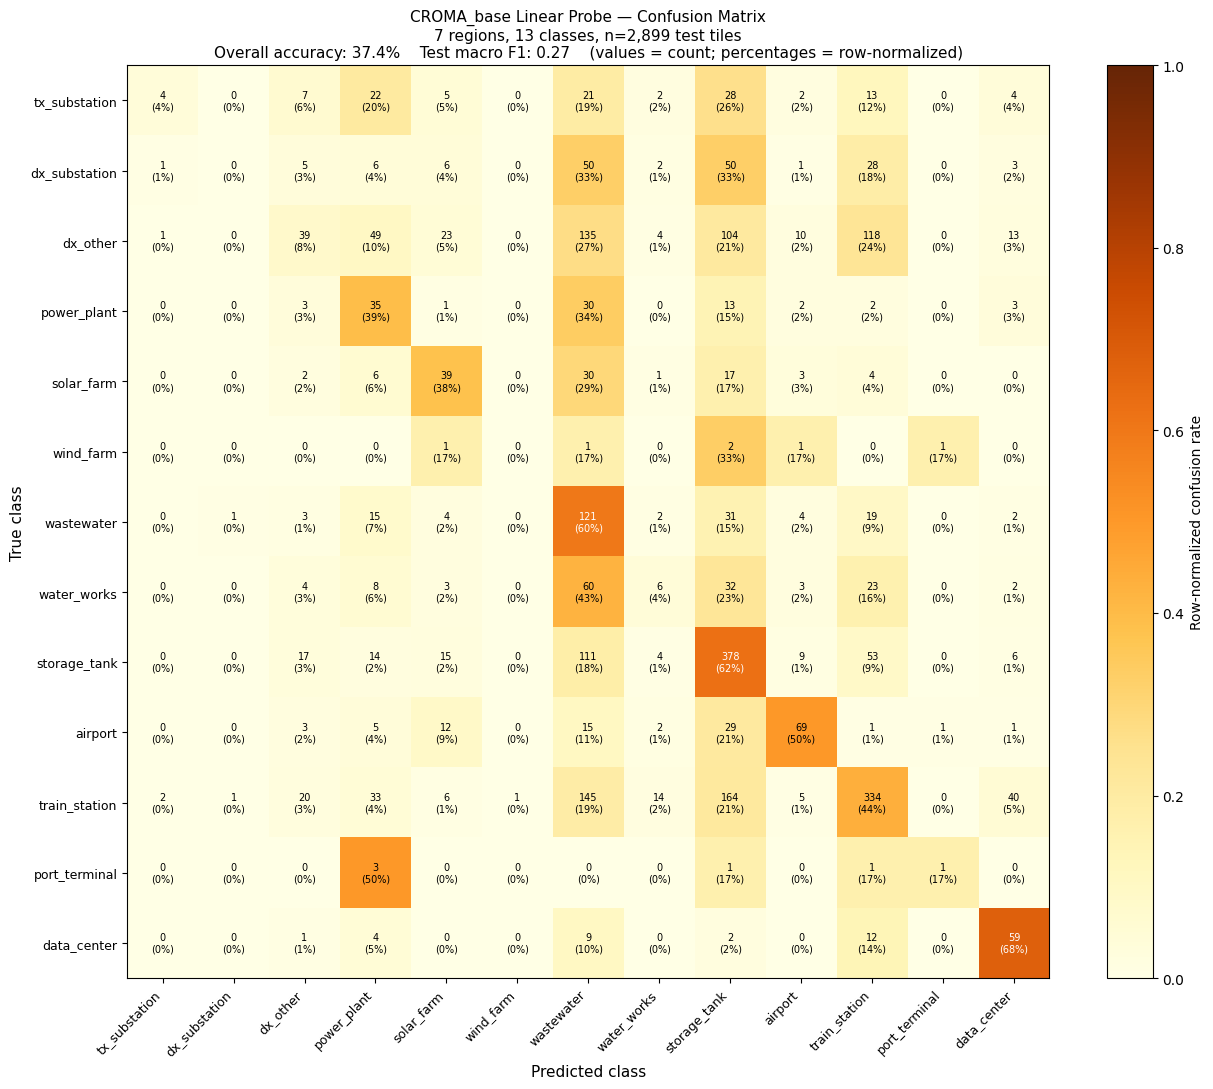


Confusion matrix saved to: /content/drive/MyDrive/infra_fm/results/fm_eval_croma_v1/confusion_matrix_croma_base_v1_linear_probe_7region.png


In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Config ---
RESULT_DIR = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_croma_v1')
RUN_NAME = 'croma_base_v1_linear_probe'
result_json_path = RESULT_DIR / f'{RUN_NAME}_results.json'
output_png_path = RESULT_DIR / f'confusion_matrix_{RUN_NAME}_7region.png'

CLASS_NAMES = [
    'tx_substation', 'dx_substation', 'dx_other',
    'power_plant', 'solar_farm', 'wind_farm',
    'wastewater', 'water_works', 'storage_tank',
    'airport', 'train_station', 'port_terminal',
    'data_center',
]

# --- Load ---
with open(result_json_path) as f:
    results = json.load(f)

# Updated to match actual schema: top → linear_probe → test
test_results = results['linear_probe']['test']
cm = np.array(test_results['confusion'])
test_acc = test_results['acc']
test_f1 = test_results['macro_f1']
n_test = int(cm.sum())

# Row-normalize
row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
cm_normalized = cm.astype(float) / row_sums

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cm_normalized, cmap='YlOrBr', vmin=0, vmax=1, aspect='auto')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = int(cm[i, j])
        pct = cm_normalized[i, j] * 100
        text_color = 'white' if cm_normalized[i, j] > 0.5 else 'black'
        ax.text(
            j, i, f'{count}\n({pct:.0f}%)',
            ha='center', va='center',
            fontsize=7, color=text_color,
        )

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel('Predicted class', fontsize=11)
ax.set_ylabel('True class', fontsize=11)

cbar = fig.colorbar(im, ax=ax, label='Row-normalized confusion rate')

ax.set_title(
    f'CROMA_base Linear Probe — Confusion Matrix\n'
    f'7 regions, 13 classes, n={n_test:,} test tiles\n'
    f'Overall accuracy: {test_acc:.1%}    Test macro F1: {test_f1:.2f}    '
    f'(values = count; percentages = row-normalized)',
    fontsize=11,
)

plt.tight_layout()
plt.savefig(output_png_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nConfusion matrix saved to: {output_png_path}')

In [13]:
import numpy as np
from sklearn.metrics import f1_score

cm = np.array(results['linear_probe']['test']['confusion'])

# Reconstruct y_true and y_pred from confusion matrix
y_true, y_pred = [], []
for true_cls in range(cm.shape[0]):
    for pred_cls in range(cm.shape[1]):
        count = int(cm[true_cls, pred_cls])
        y_true.extend([true_cls] * count)
        y_pred.extend([pred_cls] * count)

# Compute per-class F1 from this
recomputed_per_class = f1_score(y_true, y_pred, 
                                  average=None,
                                  labels=list(range(13)),
                                  zero_division=0.0)

# Compare to what's saved
saved_per_class = results['linear_probe']['test']['per_class_f1']

print('Class                              Saved F1   Recomputed F1   Match?')
print('-' * 70)
for i, name in enumerate(CLASS_NAMES):
    saved = saved_per_class[i]
    recomp = recomputed_per_class[i]
    match = '✓' if abs(saved - recomp) < 0.001 else '✗ MISMATCH'
    print(f'  [{i:>2}] {name:<30s}  {saved:.4f}     {recomp:.4f}        {match}')

Class                              Saved F1   Recomputed F1   Match?
----------------------------------------------------------------------
  [ 0] tx_substation                   0.0690     0.0690        ✓
  [ 1] dx_substation                   0.0000     0.0000        ✓
  [ 2] dx_other                        0.1300     0.1300        ✓
  [ 3] power_plant                     0.2422     0.2422        ✓
  [ 4] solar_farm                      0.3594     0.3594        ✓
  [ 5] wind_farm                       0.0000     0.0000        ✓
  [ 6] wastewater                      0.2602     0.2602        ✓
  [ 7] water_works                     0.0674     0.0674        ✓
  [ 8] storage_tank                    0.5185     0.5185        ✓
  [ 9] airport                         0.5587     0.5587        ✓
  [10] train_station                   0.4865     0.4865        ✓
  [11] port_terminal                   0.2222     0.2222        ✓
  [12] data_center                     0.5364     0.5364        ✓


In [26]:
from pathlib import Path

root = Path('/content/drive/MyDrive/infra_fm')

# Look at datasets/, v1_imagery_outputs/, and v1_sample_parquets/
for subdir_name in ['datasets', 'v1_imagery_outputs', 'v1_sample_parquets']:
    subdir = root / subdir_name
    if not subdir.exists():
        continue
    print(f'\n=== {subdir_name}/ ===')
    items = sorted(subdir.iterdir())
    for item in items[:20]:
        if item.is_dir():
            # Show first few items inside
            inner = sorted(item.iterdir())[:5]
            inner_names = [i.name for i in inner]
            print(f'  {item.name}/  (contains: {inner_names}{"..." if len(list(item.iterdir())) > 5 else ""})')
        else:
            size_mb = item.stat().st_size / 1e6
            print(f'  {item.name}  ({size_mb:.1f} MB)')
    if len(items) > 20:
        print(f'  ... and {len(items) - 20} more')


=== datasets/ ===
  dataset_africa_energy_v1_1k.zip  (45.0 MB)
  dataset_africa_stac_v1.zip  (181.2 MB)
  dataset_africa_telecom_v1_1k.zip  (0.1 MB)
  dataset_africa_transport_v1_1k.zip  (46.3 MB)
  dataset_africa_water_v1_1k.zip  (40.9 MB)
  dataset_asia_energy_v1_1k.zip  (41.4 MB)
  dataset_asia_stac_v1.zip  (762.5 MB)
  dataset_asia_telecom_v1_1k.zip  (1.4 MB)
  dataset_asia_transport_v1_1k.zip  (42.7 MB)
  dataset_asia_water_v1_1k.zip  (45.1 MB)
  dataset_australia-oceania_energy_v1_1k.zip  (49.6 MB)
  dataset_australia-oceania_stac_v1.zip  (107.5 MB)
  dataset_australia-oceania_telecom_v1_1k (1).zip  (0.6 MB)
  dataset_australia-oceania_telecom_v1_1k.zip  (0.6 MB)
  dataset_australia-oceania_transport_v1_1k.zip  (50.2 MB)
  dataset_australia-oceania_water_v1_1k.zip  (48.6 MB)
  dataset_central-america_energy_v1_1k.zip  (49.2 MB)
  dataset_central-america_stac_v1.zip  (143.4 MB)
  dataset_central-america_telecom_v1_1k.zip  (0.0 MB)
  dataset_central-america_transport_v1_1k.zip  (2

In [28]:
# Check if ALL image_date values are exactly '2024-12-31' or vary
import zipfile, json, re
from pathlib import Path
from collections import Counter

DATASETS_DRIVE = '/content/drive/MyDrive/infra_fm/datasets'
PATTERN = re.compile(r'^dataset_([a-z-]+)_(energy|water|transport|telecom)_v1_1k\.zip$')

drive_path = Path(DATASETS_DRIVE)
all_dates = Counter()

for zip_path in sorted(drive_path.glob('*.zip')):
    m = PATTERN.match(zip_path.name)
    if not m:
        continue
    region, sector = m.group(1), m.group(2)
    folder_name = f'dataset_{region}_{sector}_v1_1k'
    with zipfile.ZipFile(zip_path) as zf:
        for candidate in [f'{folder_name}/manifest.json', 'manifest.json']:
            if candidate in zf.namelist():
                with zf.open(candidate) as f:
                    manifest = json.load(f)
                for r in manifest.get('records', []):
                    all_dates[r.get('image_date')] += 1
                break

print(f'Distinct image_date values: {len(all_dates)}')
print('Top 10 most common:')
for date, count in all_dates.most_common(10):
    print(f'  {date}: {count:,}')

Distinct image_date values: 1
Top 10 most common:
  2024-12-31: 18,756


In [2]:
import os
results_dir = '/content/drive/MyDrive/infra_fm/results/fm_eval_croma_v2_spatial'
files = sorted(os.listdir(results_dir))
for f in files:
    path = os.path.join(results_dir, f)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f'{f:<60s} {size_mb:.2f} MB')
    else:
        print(f'{f}/  (dir)')

croma_v2_seed271_linear_probe/  (dir)
croma_v2_seed314_linear_probe/  (dir)
croma_v2_seed314_results.json                                0.01 MB


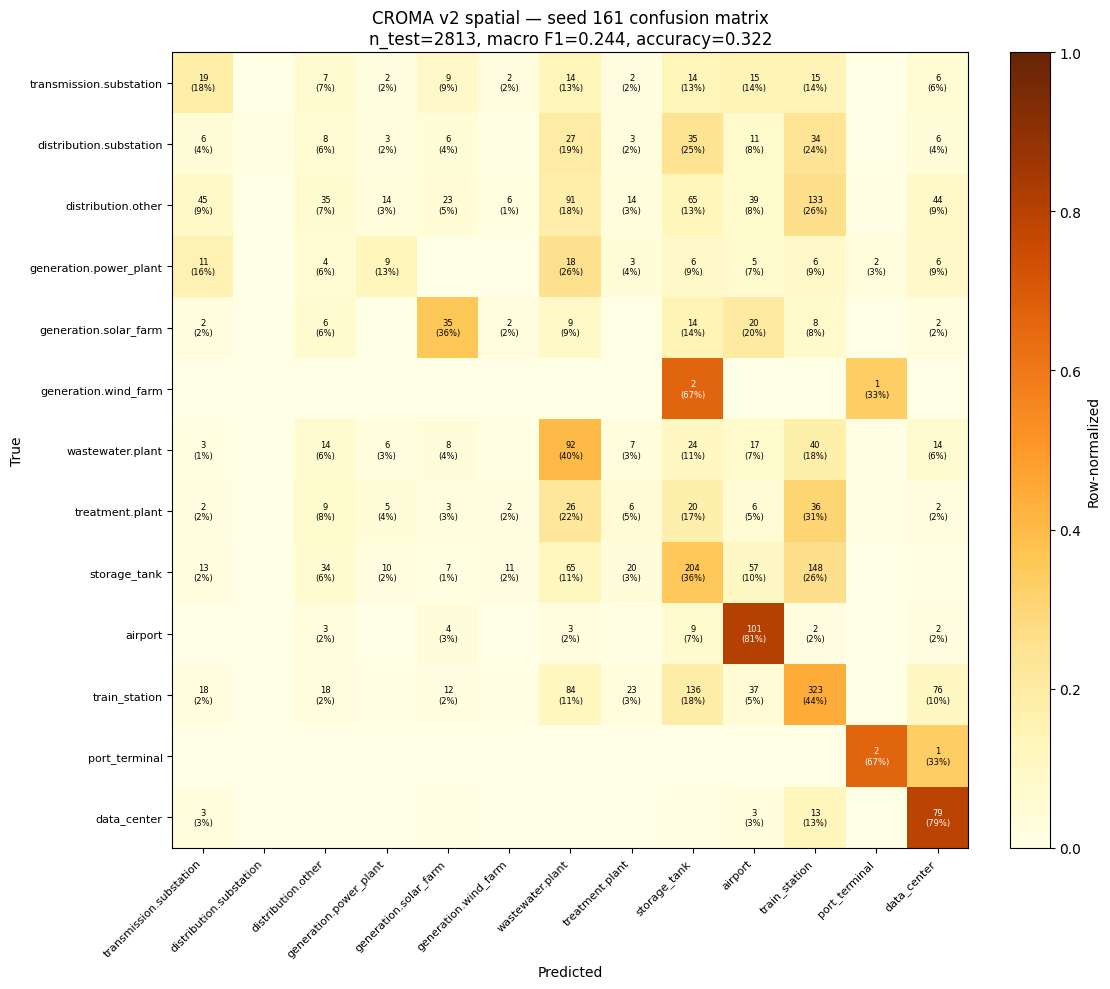


Seed 161 summary:
  Test macro F1:  0.2442
  Test accuracy:  0.3221
  Test n:         2813

Per-class F1:
  [ 0] energy.transmission.substation     F1=0.1674  test_n= 105
  [ 1] energy.distribution.substation     F1=0.0141  test_n= 141
  [ 2] energy.distribution.other          F1=0.1079  test_n= 511
  [ 3] energy.generation.power_plant      F1=0.1452  test_n=  70
  [ 4] energy.generation.solar_farm       F1=0.3398  test_n=  98
  [ 5] energy.generation.wind_farm        F1=0.0000  test_n=   3
  [ 6] water.wastewater.plant             F1=0.2801  test_n= 228
  [ 7] water.treatment.plant              F1=0.0609  test_n= 118
  [ 8] water.storage_tank                 F1=0.3696  test_n= 574
  [ 9] transport.airport                  F1=0.4633  test_n= 125
  [10] transport.train_station            F1=0.4321  test_n= 737
  [11] transport.port_terminal            F1=0.3333  test_n=   3
  [12] telecom.data_center                F1=0.4606  test_n= 100


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('/content/drive/MyDrive/infra_fm/results/fm_eval_croma_v2_spatial')
SEED = 161

# Load the seed 314 results JSON
with open(RESULTS_DIR / f'croma_v2_seed{SEED}_results.json') as f:
    results = json.load(f)

# Extract confusion matrix and class names
cm = np.array(results['linear_probe']['test']['confusion'], dtype=np.int64)
class_names = [
    'energy.transmission.substation',
    'energy.distribution.substation',
    'energy.distribution.other',
    'energy.generation.power_plant',
    'energy.generation.solar_farm',
    'energy.generation.wind_farm',
    'water.wastewater.plant',
    'water.treatment.plant',
    'water.storage_tank',
    'transport.airport',
    'transport.train_station',
    'transport.port_terminal',
    'telecom.data_center',
]
short_names = [n.split('.', 1)[1] if '.' in n else n for n in class_names]

# Row-normalize for display
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(np.float64), row_sums,
                     out=np.zeros_like(cm, dtype=np.float64),
                     where=row_sums > 0)

# Extract headline metrics
test = results['linear_probe']['test']
macro_f1 = test['macro_f1']
acc = test['acc']
n_test = cm.sum()

# Render
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap='YlOrBr', vmin=0, vmax=1)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'CROMA v2 spatial — seed {SEED} confusion matrix\n'
             f'n_test={n_test}, macro F1={macro_f1:.3f}, accuracy={acc:.3f}')

# Cell annotations: count + row-normalized %
for i in range(len(class_names)):
    for j in range(len(class_names)):
        v = cm_norm[i, j]
        count = cm[i, j]
        if v > 0.01:  # only annotate non-trivial cells
            color = 'white' if v > 0.5 else 'black'
            ax.text(j, i, f'{count}\n({v:.0%})', ha='center', va='center',
                    color=color, fontsize=6)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Row-normalized')
plt.tight_layout()
plt.show()

# Also print the summary stats
print(f'\nSeed {SEED} summary:')
print(f'  Test macro F1:  {macro_f1:.4f}')
print(f'  Test accuracy:  {acc:.4f}')
print(f'  Test n:         {n_test}')
print(f'\nPer-class F1:')
for i, name in enumerate(class_names):
    pcf1 = test['per_class_f1'][i]
    print(f'  [{i:>2d}] {name:<34s} F1={pcf1:.4f}  test_n={int(cm[i].sum()):>4d}')

In [3]:
with open(RESULTS_DIR / f'croma_v2_seed{SEED}_results.json') as f:
    results = json.load(f)
print(json.dumps(results, indent=2)[:2000])  # first 2000 chars

{
  "linear_probe": {
    "run_name": "croma_v2_seed161_linear_probe",
    "backbone": "croma_base",
    "condition": "linear_probe",
    "num_epochs": 25,
    "seed": 161,
    "best_val_f1": 0.22770639549576369,
    "best_epoch": 14,
    "tail_mean_f1": 0.203493699265068,
    "tail_std_f1": 0.011763199137490335,
    "history": [
      {
        "epoch": 1,
        "train_loss": 2.28341991502242,
        "val_acc": 0.13375350140056022,
        "val_macro_f1": 0.10410194686202251,
        "time_s": 1412.4887444972992
      },
      {
        "epoch": 2,
        "train_loss": 2.1660304930864687,
        "val_acc": 0.23109243697478993,
        "val_macro_f1": 0.14140498870014342,
        "time_s": 1413.009449005127
      },
      {
        "epoch": 3,
        "train_loss": 2.098348105510325,
        "val_acc": 0.32107843137254904,
        "val_macro_f1": 0.17040351228120904,
        "time_s": 1413.2977435588837
      },
      {
        "epoch": 4,
        "train_loss": 2.0631177034973414,